In [21]:
from openai import OpenAI
from pydantic import BaseModel

In [22]:
from dotenv import load_dotenv

In [79]:
import os
import re
import json
from pathlib import Path
import base64
import mimetypes
from glob import glob
from typing import List
import hashlib
import subprocess
import shutil
import random

In [24]:
import requests
from devtools import pprint, PrettyFormat

In [25]:
import docker

In [26]:
from moviepy import VideoFileClip, AudioFileClip, ImageClip, concatenate_videoclips

In [27]:
from IPython.display import Image
from IPython.display import Audio

In [28]:
from elevenlabs import ElevenLabs

In [29]:
from dataclasses import dataclass

In [30]:
from pydub import AudioSegment

In [31]:
pp = PrettyFormat()

In [32]:
load_dotenv()

True

In [33]:
llm_client = OpenAI()

In [34]:
docker_client = docker.from_env()

### Utility functions

In [35]:
def image_to_data_url(path: str | Path) -> str:
    path = Path(path).expanduser().resolve()

    mime_type, _ = mimetypes.guess_type(path)
    if mime_type is None:
        mime_type = "application/octet-stream"

    image_bytes = path.read_bytes()

    b64_encoded = base64.b64encode(image_bytes).decode("ascii")

    return f"data:{mime_type};base64,{b64_encoded}"

In [43]:
image_dataset = glob('../dataset/images/exam_questions/*.png')

## 00. Clean up previous run

In [44]:
for folder in ["audio", "output", "manim"]:
    if os.path.exists(folder):
        shutil.rmtree(folder)

## 01. Context gathering

In [48]:
problem_image = sorted(image_dataset)[0]

In [49]:
problem_image

'dataset/images/exam_questions/2020_q1.png'

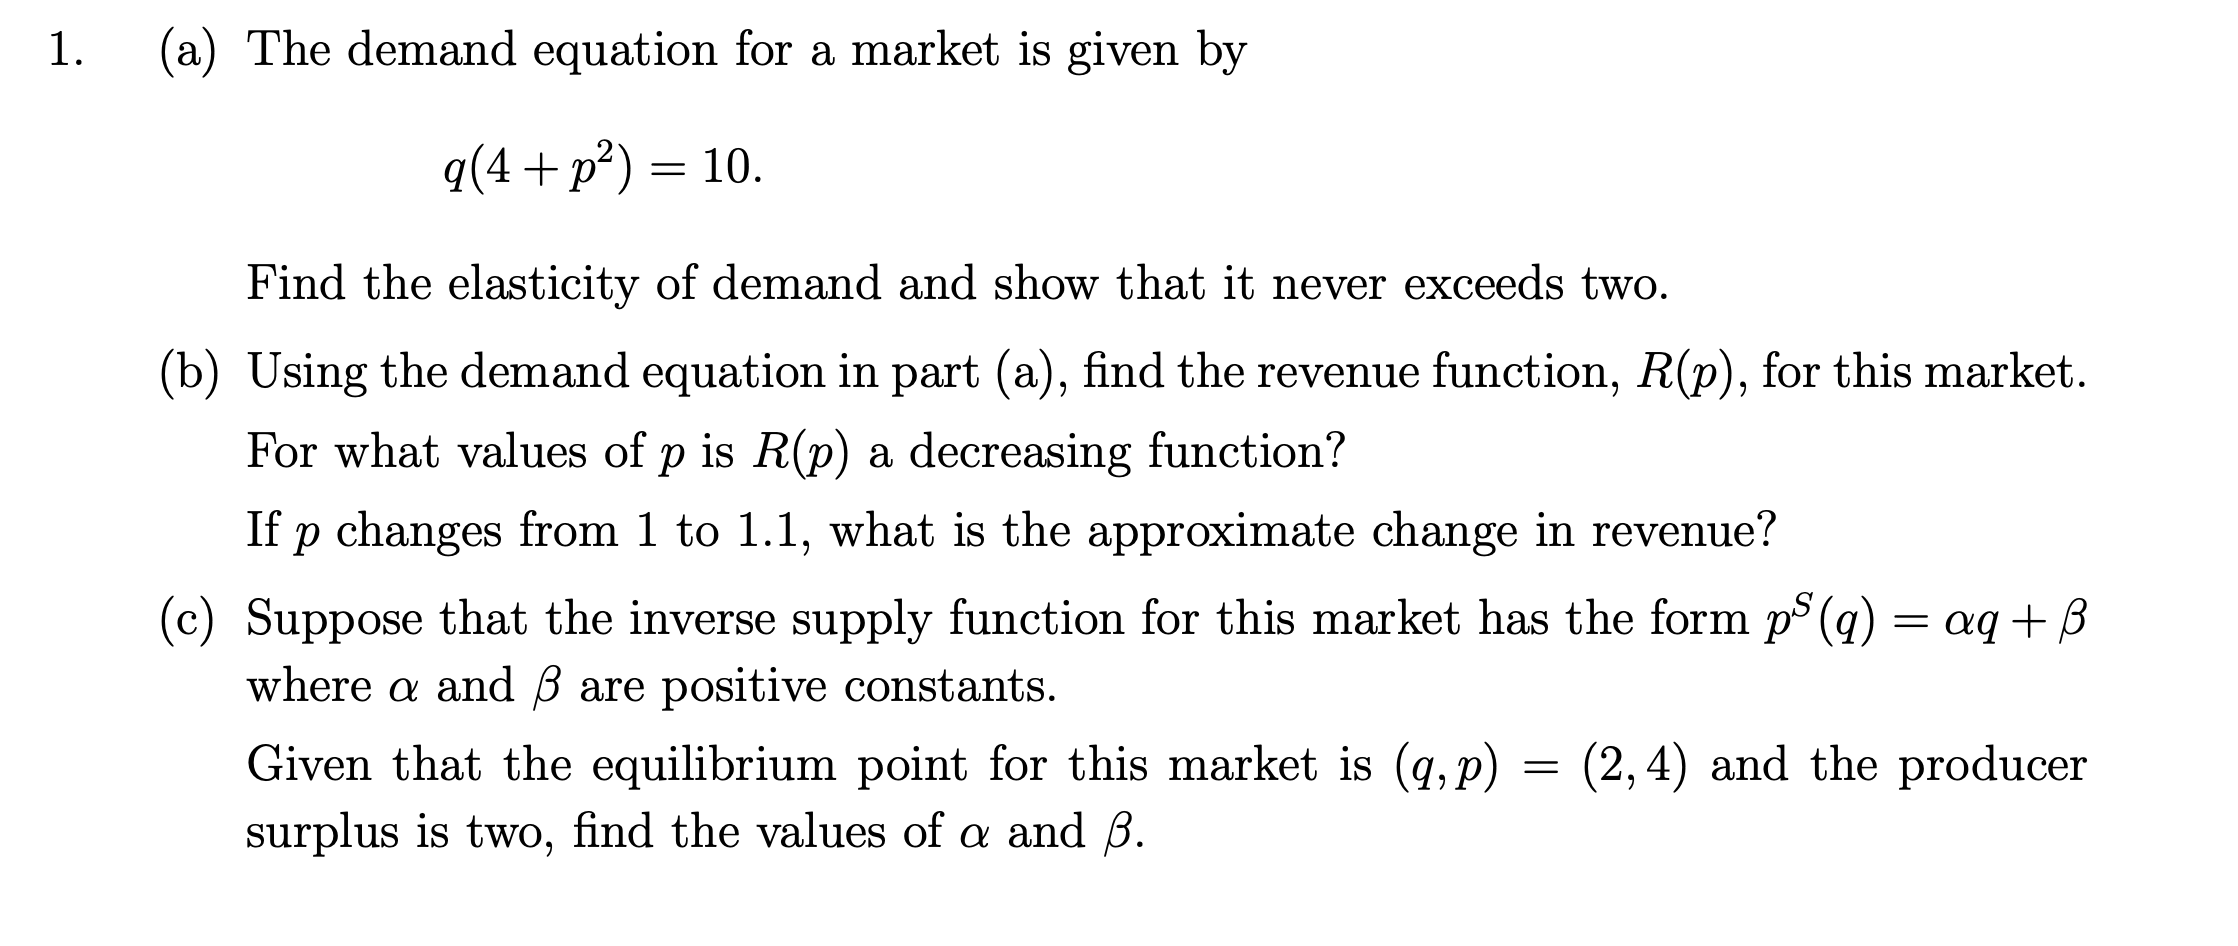

In [50]:
Image(problem_image)

## 02. Problem extraction

In [51]:
class Equations(BaseModel):
    latext: str
    unicode: str

class Prerequisites(BaseModel):
    topic: str
    reason: str

class Givens(BaseModel):
    known_facts: str
    explanation: str

class ProblemAnalysis(BaseModel):
    equations: list[Equations]
    problem_description: str
    prerequisites: list[Prerequisites]
    givens: list[Givens]

In [52]:
response = llm_client.responses.parse(
    model="o3",
    input=[{
        "role": "user",
        "content": [
            {"type": "input_text", "text": "Extract the equations, description of the maths problem, prerequisite required knowledge and known 'givens' in the problem which are helpful in answering the question."},
            {
                "type": "input_image",
                "image_url": image_to_data_url(problem_image)
            },
        ],
    }],
    text_format=ProblemAnalysis
)

In [53]:
problem_analysis = response.output_parsed

In [54]:
pprint(problem_analysis.equations[0])

Equations(
    latext='q\\left(4+p^{2}\\right)=10',
    unicode='q(4+p²)=10',
)


In [55]:
pprint(problem_analysis)

ProblemAnalysis(
    equations=[
        Equations(
            latext='q\\left(4+p^{2}\\right)=10',
            unicode='q(4+p²)=10',
        ),
        Equations(
            latext='p^{S}(q)=\\alpha q+\\beta',
            unicode='pᵂ(q)=αq+β',
        ),
    ],
    problem_description=(
        'The problem concerns a single market with a specified nonlinear demand curve.  You are asked to:\n'
        '(a) Compute the price–elasticity of demand and show it is never greater than two.\n'
        '(b) Use the same demand equation to derive the revenue function R(p), decide for which prices revenue is decr'
        'easing, and estimate the change in revenue when price rises from 1 to 1.1.\n'
        '(c) Assume an affine (linear) inverse-supply curve, find its parameters α and β when the market equilibrium i'
        's (q,p)=(2,4) and producer surplus equals 2.'
    ),
    prerequisites=[
        Prerequisites(
            topic='Differential calculus',
            reason=(
          

## 03. Solution solving steps

In [56]:
class ProblemSolvingStep(BaseModel):
    title: str
    description: str
    hints: str

class Solution(BaseModel):
    steps: list[ProblemSolvingStep]
    final_solution: str

In [57]:
solution_step_prompt = f"""Solve this problem step-by-step:

{problem_analysis.problem_description}

The first step should be analysing the problem, identifying the relevant topics necessary to approach this problem and "givens" as part of the question.

The solution solving steps should be related to this curriculum of learning outcomes from the first year University of London Mathematical Methods course:

```
FUNCTIONS AND DIFFERENTIATION

use identities to rewrite expressions involving powers, logarithms, and trigonometric functions

solve problems from economics-based subjects that involve functions

find simple derivatives using the definition of the derivative

find derivatives using standard derivatives and the rules of differentiation

use the derivative to find tangent lines and use these to approximate functions

solve problems from economics-based subjects that involve derivatives.

ONE VARIABLE OPTIMISATION

use identities to rewrite expressions involving powers, logarithms, and trigonometric functions

solve problems from economics-based subjects that involve functions

find simple derivatives using the definition of the derivative

find derivatives using standard derivatives and the rules of differentiation

use the derivative to find tangent lines and use these to approximate functions

solve problems from economics-based subjects that involve derivatives.

INTEGRATION—FUNDAMENTALS

use first- and second-order derivatives to identify the relevant features of a function

sketch curves by identifying their key features

optimise functions of one variable

solve problems from economics-based subjects that involve optimisation.

INTEGRATION—CONTINUED

find integrals using integration by substitution

find integrals using integration by parts

find integrals by simplifying the integrand using partial fractions and trigonometric identities.

FUNCTIONS OF SEVERAL VARIABLES

visualise a surface by using sections and contours

find partial derivatives

use the chain rule to find derivatives of various kinds

show that a function is homogeneous and verify Euler's theorem

solve problems from economics-based subjects that involve partial derivatives.

MULTIVARIATE OPTIMISATION

find and classify the stationary points of a function of two variables

solve problems from economics-based subjects that involve unconstrained optimisation

optimise a function in the presence of constraints

solve problems from economics-based subjects that involve constrained optimisation.

MATRICES AND LINEAR EQUATIONS

perform the given operations on vectors and matrices

use cofactor expansions to find determinants

determine whether a matrix is invertible and, if it is, find its inverse

solve systems of linear equations using row operations, an inverse matrix, or Cramer's rule, as appropriate.

DIFFERENTIAL EQUATIONS

identify and solve separable and linear first-order ODEs

identify and solve homogeneous and non-homogeneous second-order ODEs with constant coefficients

solve coupled systems of first-order ODEs

solve problems from economics-based subjects that involve applications of ODEs.

DIFFERENCE EQUATIONS

identify and solve first-order difference equations

identify and solve homogeneous and non-homogeneous second-order difference equations

solve coupled systems of first-order difference equations

solve problems from economics-based subjects that involve applications of difference equations.

DIAGONALISATION

find the eigenvalues and eigenvectors of a 2 x 2 matrix

diagonalise a 2 x 2 matrix

use diagonalisation to solve coupled systems of first-order differential and difference equations

solve problems that involve the cobweb model.
```


Relevant LaTeX equation:

""" + '\n'.join([e.latext for e in problem_analysis.equations])

In [58]:
print(solution_step_prompt)

Solve this problem step-by-step:

The problem concerns a single market with a specified nonlinear demand curve.  You are asked to:
(a) Compute the price–elasticity of demand and show it is never greater than two.
(b) Use the same demand equation to derive the revenue function R(p), decide for which prices revenue is decreasing, and estimate the change in revenue when price rises from 1 to 1.1.
(c) Assume an affine (linear) inverse-supply curve, find its parameters α and β when the market equilibrium is (q,p)=(2,4) and producer surplus equals 2.

The first step should be analysing the problem, identifying the relevant topics necessary to approach this problem and "givens" as part of the question.

The solution solving steps should be related to this curriculum of learning outcomes from the first year University of London Mathematical Methods course:

```
FUNCTIONS AND DIFFERENTIATION

use identities to rewrite expressions involving powers, logarithms, and trigonometric functions

solve 

In [59]:
problem_response = llm_client.responses.parse(
    model="o3",
    input=[{
        "role": "user",
        "content": [
            {"type": "input_text", "text": solution_step_prompt},
        ],
    }],
    text_format=Solution
)

In [60]:
pprint(problem_response.output_parsed.steps)

[
    ProblemSolvingStep(
        title='Read the problem and list the ‘givens’',
        description=(
            '• Demand curve (in direct form):   q(4+p^{2})=10  ⇒  q(p)=10/(4+p^{2}).\n'
            '• We need: (a) price–elasticity, (b) revenue function, monotonicity, small change in R, (c) linear invers'
            'e–supply p^{S}(q)=αq+β with equilibrium (q*,p*)=(2,4) and producer surplus (PS)=2.'
        ),
        hints='Topics: derivatives, elasticity, optimisation of one variable, definite integrals.',
    ),
    ProblemSolvingStep(
        title='Differentiate the demand function',
        description=(
            'q(p)=10/(4+p^{2}) =10(4+p^{2})^{-1}\n'
            '⇒ dq/dp =10·(-1)(4+p^{2})^{-2}(2p) = -20p/(4+p^{2})^{2}.'
        ),
        hints="Rule used: d/dp (u^{-1}) = -u'/u^{2}  (chain rule).",
    ),
    ProblemSolvingStep(
        title='Compute price–elasticity ε(p)',
        description=(
            'ε(p)= (dq/dp)(p/q) = [-20p/(4+p^{2})^{2}]·[p /(10/(4+p^{2}))

## 04. Gotchas

In [61]:
# TODO

Intention for this workflow is to analyse each ProblemSolvingStep and determine if there are any common mistakes learners may make when approaching this problem.

## 05. Verify solution correctness

In [62]:
# TODO using Sympy

#### Example of generated sympy script for validating solution correctness

This is using one of the fixture examples of an Integration problem

In [380]:
from sympy import (
    Symbol,
    integrate,
    diff,
    simplify,
    lambdify,
    log,
    pretty,
)

In [381]:
x = Symbol("x", real=True)
integrand = x**2 / (x**2 - 1)

antiderivative = integrate(integrand, x)

# SymPy’s default form is  x + log(x - 1)/2 - log(x + 1)/2 .
# A prettier compact version uses log((x - 1)/(x + 1)):
antiderivative = simplify(antiderivative)  # triggers the log-difference identity

print("Computed antiderivative F(x):\n")
print(pretty(antiderivative))

Computed antiderivative F(x):

    log(x - 1)   log(x + 1)
x + ────────── - ──────────
        2            2     


In [382]:
# ----------------------------------------------------------------------
# Symbolic verification  F'(x) == integrand
# ----------------------------------------------------------------------
sym_diff = diff(antiderivative, x)
sym_check = simplify(sym_diff - integrand)

In [383]:
print(pretty(sym_diff))

        1           1    
1 - ───────── + ─────────
    2⋅(x + 1)   2⋅(x - 1)


In [384]:
print("Difference after simplification: " + str(sym_check))

Difference after simplification: 0


## 06. Manim generation

In [63]:
manim_prompt = """
You are an expert Manim-CE animator and math instructor.

**Task**  
Write a single Python script called **`solve_problem.py`** (Manim CE ≥ 0.18).  
The script must define **one Scene class per solution step** so that each scene can be rendered separately:

| Scene class | Corresponds to | Render command example |
|-------------|----------------|------------------------|
""" + "\n".join(
        [
            f"| `Step{idx+1}(Scene) | '{step.title}' | `manim -pqh solve_problem.py Step{idx+1} -o step_{idx+1}` |" 
            for idx, step in enumerate(problem_response.output_parsed.steps)
        ]
    ) + """

**For *each* scene**  
1. Use a dark background (`BACKGROUND_COLOR = "#1e1e1e"`).  
2. Display the step title in a banner at the top (semi-transparent `BLUE_E`).  
3. Show and animate the LaTeX equations with `MathTex`; highlight changes (`YELLOW`, `ORANGE`).  
4. Keep ~0.5 s waits between minor animations, ~1 s between major ones.  
5. Finish the scene with a short pause (0.5 s) so the last frame isn’t cut off.
6. If a visualisation enhances understanding, such as a contour or graph, then include this on the slide.

**Global visual style**  
- Text `WHITE`, titles 48 pt, equations 36 pt.  
- Use `FadeIn`, `Transform`, `Circumscribe`, and mild `LaggedStart`.  
- No audio handling — narration will be added later.

**Input data (do not alter)**  

```python
"""+pp(problem_analysis)+"""

"""+pp(problem_response.output_parsed)+"""
```

Output
Return only the contents of solve_problem.py—no extra comments—so each scene can be rendered like:

```bash
manim -pqh solve_problem.py Step1 -o step_1
manim -pqh solve_problem.py Step2 -o step_2
...
```

Constraints

Wrap repeated UI elements (title banner, highlight routine) in helper functions.

Ensure each scene renders at -pqh quality in ≤ 90 s on a modest laptop.
"""


In [64]:
print(manim_prompt)


You are an expert Manim-CE animator and math instructor.

**Task**  
Write a single Python script called **`solve_problem.py`** (Manim CE ≥ 0.18).  
The script must define **one Scene class per solution step** so that each scene can be rendered separately:

| Scene class | Corresponds to | Render command example |
|-------------|----------------|------------------------|
| `Step1(Scene) | 'Read the problem and list the ‘givens’' | `manim -pqh solve_problem.py Step1 -o step_1` |
| `Step2(Scene) | 'Differentiate the demand function' | `manim -pqh solve_problem.py Step2 -o step_2` |
| `Step3(Scene) | 'Compute price–elasticity ε(p)' | `manim -pqh solve_problem.py Step3 -o step_3` |
| `Step4(Scene) | 'Show |ε(p)|<2 for every p≥0' | `manim -pqh solve_problem.py Step4 -o step_4` |
| `Step5(Scene) | 'Form the revenue function' | `manim -pqh solve_problem.py Step5 -o step_5` |
| `Step6(Scene) | 'Find dR/dp and where R is decreasing' | `manim -pqh solve_problem.py Step6 -o step_6` |
| `Step7(Sc

In [65]:
manim_script = llm_client.responses.create(
    model="o3",
    input=[{
        "role": "user",
        "content": [
            {"type": "input_text", "text": manim_prompt},
        ],
    }],
)

In [66]:
pprint(manim_script.output[1].content[0].text)

(
    '```python\n'
    '# solve_problem.py\n'
    'from manim import *\n'
    '\n'
    '# ------------------------  GLOBAL STYLE  ------------------------ #\n'
    'config.background_color = "#1e1e1e"\n'
    'TITLE_FONT_SIZE = 48\n'
    'EQ_FONT_SIZE = 36\n'
    'SMALL_WAIT = 0.5\n'
    'BIG_WAIT = 1.0\n'
    '\n'
    '# ------------------------  HELPERS  ------------------------ #\n'
    'def banner(title: str) -> VGroup:\n'
    '    """Semi-transparent banner that stays on screen."""\n'
    '    rect = Rectangle(\n'
    '        width=14, height=1,\n'
    '        stroke_width=0,\n'
    '        fill_color=BLUE_E,\n'
    '        fill_opacity=0.4\n'
    '    ).to_edge(UP)\n'
    '    txt = Text(title, font_size=TITLE_FONT_SIZE, color=WHITE).move_to(rect)\n'
    '    return VGroup(rect, txt)\n'
    '\n'
    '\n'
    'def show_eqn(scene: Scene, *tex_strings: str):\n'
    '    """\n'
    '    Convenience: write each LaTeX string one under the other.\n'
    '    Returns VGroup of equati

In [67]:
# Cleaning markdown backticks (```python ... ```) from first and last lines
cleaned_manim_script = '\n'.join(manim_script.output[1].content[0].text.split('\n')[1:-1])

### Warning!

<span style="color: red">Do not run arbitrary Python scripts generated by LLMs without checking it first!</span>

Inspect its contents and run in an isolated environment, like a Docker container.

In [68]:
# Use docker to execute Manim for each individual script

In [69]:
host_dir = Path.cwd() / "manim"

In [70]:
os.makedirs(host_dir, exist_ok=True)
with open('manim/solve_problem.py', 'w') as f:
    f.write(cleaned_manim_script)

In [71]:
volumes = {
    str(host_dir.resolve()): {
        "bind": "/manim",
        "mode": "rw",
    }
}

In [72]:
for idx, step in enumerate(problem_response.output_parsed.steps):
    container = docker_client.containers.run(
        image="manimcommunity/manim",
        command=f"manim -pqh solve_problem.py Step{idx+1} -o step_{idx+1}",
        working_dir="/manim",
        volumes=volumes,
        tty=True,
        stdin_open=True,
        auto_remove=True,
        detach=True
    )

    result = container.wait()
    print("Exit code:", result.get("StatusCode", "unknown"))

Exit code: 1
Exit code: 1
Exit code: 1
Exit code: 1
Exit code: 1
Exit code: 1
Exit code: 1
Exit code: 1
Exit code: 1
Exit code: 1


In [73]:
# It errors with exit code 1 but still produces the videos successfully. To investigate.

In [74]:
video_step_files = glob("manim/media/videos/solve_problem/1080p60/*.mp4")

In [75]:
video_step_files

['manim/media/videos/solve_problem/1080p60/step_10.mp4',
 'manim/media/videos/solve_problem/1080p60/step_8.mp4',
 'manim/media/videos/solve_problem/1080p60/step_9.mp4',
 'manim/media/videos/solve_problem/1080p60/step_7.mp4',
 'manim/media/videos/solve_problem/1080p60/step_4.mp4',
 'manim/media/videos/solve_problem/1080p60/step_5.mp4',
 'manim/media/videos/solve_problem/1080p60/step_1.mp4',
 'manim/media/videos/solve_problem/1080p60/step_2.mp4',
 'manim/media/videos/solve_problem/1080p60/step_3.mp4']

In [76]:
# Get the last frame of each slide to build up the script

In [82]:
def extract_last_frame(video, out_png=None):
    video = Path(video)
    if out_png is None:
        out_png = video.with_suffix(".last.png")

    probe_cmd = [
        "ffprobe", "-v", "error",
        "-select_streams", "v:0",
        "-count_frames",
        "-show_entries", "stream=nb_read_frames",
        "-print_format", "json",
        str(video)
    ]
    nb_frames = int(json.loads(subprocess.check_output(probe_cmd))
                    ["streams"][0]["nb_read_frames"])

    select_filter = f"select=eq(n\\,{nb_frames-1})"
    ff_cmd = [
        "ffmpeg", "-hide_banner", "-loglevel", "error", "-y",
        "-i", str(video),
        "-vf", select_filter,
        "-vframes", "1",
        str(out_png)
    ]
    subprocess.run(ff_cmd, check=True)
    return Path(out_png)


videos = sorted(Path("manim/media/videos/solve_problem/1080p60").glob("step_*.mp4"))
for v in videos:
    png = extract_last_frame(v)
    print("✓", png)

✓ manim/media/videos/solve_problem/1080p60/step_1.last.png
✓ manim/media/videos/solve_problem/1080p60/step_10.last.png
✓ manim/media/videos/solve_problem/1080p60/step_2.last.png
✓ manim/media/videos/solve_problem/1080p60/step_3.last.png
✓ manim/media/videos/solve_problem/1080p60/step_4.last.png
✓ manim/media/videos/solve_problem/1080p60/step_5.last.png
✓ manim/media/videos/solve_problem/1080p60/step_7.last.png
✓ manim/media/videos/solve_problem/1080p60/step_8.last.png
✓ manim/media/videos/solve_problem/1080p60/step_9.last.png


## 07. Script dialogue generation

In [83]:
s1_personality = "Warm and steady mentor; calm mid-pitch voice, measured pace; frequent gentle affirmations (“great job”, “exactly”); uses clear analogies and mild humour to lower anxiety."
s2_personality = "Curious, energetic learner; slightly higher pitch and faster tempo; sprinkles in genuine wonder (“oh, I see!”, “that’s neat”); not afraid to admit confusion, eager to try answers."

In [84]:
elevenlabs_prompt = r"""
You are designing **dialogue scripts** that will be rendered with the
**ElevenLabs Text-to-Speech API** (multi-voice).  
Two distinct voices will be used:

| Tag | Persona | Voice-ID (placeholder) | Personality cues |
|-----|---------|------------------------|------------------|
| `[S1]` | Teacher | `<VOICE_ID_TEACHER>` | """+s1_personality+""" |
| `[S2]` | Student | `<VOICE_ID_STUDENT>` | """+s2_personality+""" |

(Our orchestration layer will swap the placeholders for real voice IDs
before calling ElevenLabs.)

───────────────────────────
Conversation specification
───────────────────────────
For **each problem-solving step** in `Solution.steps`, generate a short,
self-contained chat that matches the final slide frame for that step.

1. **Length** 10 – 30 utterances total, focusing on being an engaging conversation to drive understanding and help students learn.
2. **Tone** friendly “chalk & talk”; S1 guides, S2 thinks aloud. Add colour and personality to the conversation with liberal use metaphors.
3. **Slide awareness** Mention what part of the slide the speaker is referring to if it aids in understanding. Do **not** restate the full equation.
4. **Pedagogical arc** S1 → question → S2 reply → S1 confirm/correct → S2 cements understanding → S1 encourages and celebrates → wrap-up.  
5. **Pronunciation control** ElevenLabs mispronounces raw math
   symbols; **spell them out**:

   | Symbol | Say … |
   |--------|-------|
   | `x²`   | “x squared” |
   | `/`    | “divided by” |
   | `∫`    | “integral of” |
   | `→`    | “implies” |
   | `ln`   | “natural log” |

   *Never* include LaTeX, superscripts or subscripts directly.
6. **No extra stage directions** beyond the allowed tag.  
7. **Order** Do **not** merge steps; output chats in the same order as
   `Solution.steps`.
8. The first interaction on the first slide should introduce the whole problem, give an overview and describe all the prerequisities which are necessary to tackle this problem.
9. The whole conversation should be coherent, engaging and fun. Students watching this video should have more con

──────────────────────────────
Example (abridged, symbol-safe)
──────────────────────────────
Step 2 – Partial Fractions  
[S1] Notice the denominator—see “x minus one” times “x plus one”?  
[S2] Yes! That means we can split the fraction, right?  
[S1] Exactly. What constants should we place on top?  
[S2] Let me guess: A over “x minus one” and B over “x plus one.”  
[S1] Good. Plugging in x equals one gives A equals one-half—keep going!

────────────────────────────────────────────────────────────
**Input data**

```python
""" + pp(problem_analysis) + """

""" + pp(problem_response.output_parsed) + """
"""

In [85]:
base64_slide_images = [{"type": "input_image", "image_url": image_to_data_url(i)} for i in glob("manim/media/videos/solve_problem/1080p60/*.last.png")]

In [86]:
# script_collected_prompt = [{ "type": "input_text", "text": dia_prompt }] + base64_slide_images
script_collected_prompt = [{ "type": "input_text", "text": elevenlabs_prompt }] + base64_slide_images

In [87]:
class StepConversation(BaseModel):
    step: str
    script: str

class ConversationScript(BaseModel):
    steps: list[StepConversation]

In [88]:
script_response = llm_client.responses.parse(
    model="o3",
    input=[{
        "role": "user",
        "content": script_collected_prompt,
    }],
    text_format=ConversationScript
)

In [89]:
pprint(script_response.output_parsed)

ConversationScript(
    steps=[
        StepConversation(
            step='Step 1 – Read the problem & list the “givens”',
            script=(
                '[S1] Welcome aboard! Today we’re sailing through a single-market problem that mixes calculus with mic'
                'ro-economics. Ready, first mate?\n'
                '[S2] Aye aye, captain! But give me the map before we cast off.\n'
                '[S1] Look at the top of the slide: the demand relation says quantity times “four plus p squared” equa'
                'ls ten. From that we can always solve for quantity as ten divided by that bracket.\n'
                '[S2] So quantity shrinks as price goes up—classic downward slope.\n'
                '[S1] Exactly, great observation. Now, three treasure chests to open: \n'
                '         a) compute the price elasticity, \n'
                '         b) analyse revenue and its change from price one to one point one, \n'
                '         c) pin down an

In [90]:
conversation_script = script_response.output_parsed

In [91]:
conversation_script.steps[0].script

'[S1] Welcome aboard! Today we’re sailing through a single-market problem that mixes calculus with micro-economics. Ready, first mate?\n[S2] Aye aye, captain! But give me the map before we cast off.\n[S1] Look at the top of the slide: the demand relation says quantity times “four plus p squared” equals ten. From that we can always solve for quantity as ten divided by that bracket.\n[S2] So quantity shrinks as price goes up—classic downward slope.\n[S1] Exactly, great observation. Now, three treasure chests to open: \n         a) compute the price elasticity, \n         b) analyse revenue and its change from price one to one point one, \n         c) pin down an unknown linear supply curve using equilibrium and producer surplus.\n[S2] I see bullets labelled equilibrium at two comma four and producer surplus equals two. Those will be my compass later.\n[S1] Spot on. Prerequisites check: differential calculus for slopes, marginal analysis for that tiny price bump, algebra juggling, and a d

In [92]:
# model dump json script

# 08. Text to Speech

In [93]:
os.makedirs("audio", exist_ok=True)

### ElevenLabs voice generation

In [94]:
elevenlabs_client = ElevenLabs(
    api_key=os.environ["ELEVENLABS_API_KEY"]
)

In [95]:
ELEVENLABS_MODEL_NAME = 'eleven_multilingual_v2'

In [103]:
# ─────────────────────────────────────────────────────────────
# helper: deterministic cache filename  (voice│text → hash)
# ─────────────────────────────────────────────────────────────
def cache_path(step_idx: str, role: str, text: str, voice_id: str) -> Path:
    h = hashlib.sha256(f"{voice_id}|{text}".encode()).hexdigest()[:16]
    return Path("audio") / f"step_{step_idx}_{role}_{h}.wav"

In [104]:
voice_ids_list = [
    'NOpBlnGInO9m6vDvFkFC', 
    'yl2ZDV1MzN4HbQJbMihG',
    'kdmDKE6EkgrWrrykO9Qt',
    '56AoDkrOh6qfVPDXZ7Pt',
    'vfaqCOvlrKi4Zp7C2IAm',
    'KTPVrSVAEUSJRClDzBw7',
    'yjJ45q8TVCrtMhEKurxY',
    'pPdl9cQBQq4p6mRkZy2Z',
    'vBKc2FfBKJfcZNyEt1n6',
    'piI8Kku0DcvcL6TTSeQt',
    'tnSpp4vdxKPjI9w0GnoV',
    'DTKMou8ccj1ZaWGBiotd',
    'flHkNRp1BlvT73UL6gyz',
    '9yzdeviXkFddZ4Oz8Mok',
    'UgBBYS2sOqTuMpoF3BR0',
    '0SpgpJ4D3MpHCiWdyTg3',
    'oR4uRy4fHDUGGISL0Rev',
    '1hlpeD1ydbI2ow0Tt3EW',
    'DtsPFCrhbCbbJkwZsb3d',
    'gOkFV1JMCt0G0n9xmBwV'
]

In [105]:
selected_voices = random.sample(voice_ids_list, 2)

voice_map = {
    '[S1]': selected_voices[0],
    '[S2]': selected_voices[1]
}

In [107]:
conversation_script.steps[0].script.split("\n")

['[S1] Welcome aboard! Today we’re sailing through a single-market problem that mixes calculus with micro-economics. Ready, first mate?',
 '[S2] Aye aye, captain! But give me the map before we cast off.',
 '[S1] Look at the top of the slide: the demand relation says quantity times “four plus p squared” equals ten. From that we can always solve for quantity as ten divided by that bracket.',
 '[S2] So quantity shrinks as price goes up—classic downward slope.',
 '[S1] Exactly, great observation. Now, three treasure chests to open: ',
 '         a) compute the price elasticity, ',
 '         b) analyse revenue and its change from price one to one point one, ',
 '         c) pin down an unknown linear supply curve using equilibrium and producer surplus.',
 '[S2] I see bullets labelled equilibrium at two comma four and producer surplus equals two. Those will be my compass later.',
 '[S1] Spot on. Prerequisites check: differential calculus for slopes, marginal analysis for that tiny price bum

In [110]:
TAG_RE = re.compile(r"^\[S[12]\]") 

In [111]:

def parse_turns(raw_script: str) -> list[str]:
    """Return clean speaker-turn strings that always start with [S1] / [S2]."""
    turns, current = [], []
    for line in raw_script.splitlines():
        stripped = line.rstrip()
        if not stripped:                   # skip empty lines
            continue
        if TAG_RE.match(stripped):         # new speaker
            if current:
                turns.append(" ".join(current))
            current = [stripped]
        else:                              # continuation of previous speaker
            current.append(stripped)
    if current:
        turns.append(" ".join(current))
    return turns

In [112]:
for step_idx, step in enumerate(conversation_script.steps):
    print(f"\n🎬  === Step {step_idx+1} ===")
    prev_request_ids: list[str] = []

    speaker_turns = parse_turns(step.script)
    speaker_turn_count = len(speaker_turns)
    step_wav_files = []

    for turn_idx, turn in enumerate(speaker_turns):
        role, text = turn[:4], turn[4:].lstrip()
        print(f"Role: {role}")
        print(f"Text: {text}")

        voice_id = voice_map[role]

       
        wav_path = cache_path(step_idx, role, turn, voice_id)
        if wav_path.exists():
            step_wav_files.append(wav_path)
            print(f"↪︎  cache hit  {wav_path.name}")
            continue

        # prepare context fields
        prev_text = None if turn_idx == 0 else " ".join(speaker_turns[:turn_idx])
        next_text = None if turn_idx == speaker_turn_count - 1 else " ".join(speaker_turns[turn_idx + 1 :])

        # call ElevenLabs via SDK
        audio_bytes = elevenlabs_client.text_to_speech.convert(
            text           = text,
            voice_id       = voice_id,
            model_id       = ELEVENLABS_MODEL_NAME,
            voice_settings = {
                "speed": 1.2,
                #"use_speaker_boost": True,
                "style": 0.5,
                #"similarity_boost": 0.7,
                "stability": 0.3
            },
            # context
            previous_text            = prev_text,
            next_text                = next_text,
            previous_request_ids     = prev_request_ids[-3:],
            # true to see if normalization will also enhance pronunciation
            apply_text_normalization = 'on'
        )

        with open(wav_path, 'wb') as f:
            audio = b"".join(audio_bytes)
            f.write(audio)
        
        req_id = elevenlabs_client.history.get_all().history[0].request_id
        if req_id:
            prev_request_ids.append(req_id)

        step_wav_files.append(wav_path)
        print(f"✓  {wav_path.name}   req_id={req_id}")
    
    # combine all step_wav_files files
    # -----------------------------------------------------------
    if step_wav_files:
        combined = AudioSegment.from_file(step_wav_files[0])
        for extra in step_wav_files[1:]:
            combined += AudioSegment.from_file(extra)

        out_slide = Path("audio") / "combined" / f"step_{step_idx+1}.wav"
        out_slide.parent.mkdir(parents=True, exist_ok=True)
        combined.export(out_slide, format="wav")
        print("🔊  wrote", out_slide.name)


🎬  === Step 1 ===
Role: [S1]
Text: Welcome aboard! Today we’re sailing through a single-market problem that mixes calculus with micro-economics. Ready, first mate?
↪︎  cache hit  step_0_[S1]_76647ca8317a3bb9.wav
Role: [S2]
Text: Aye aye, captain! But give me the map before we cast off.
↪︎  cache hit  step_0_[S2]_96cdeb43a8a26460.wav
Role: [S1]
Text: Look at the top of the slide: the demand relation says quantity times “four plus p squared” equals ten. From that we can always solve for quantity as ten divided by that bracket.
↪︎  cache hit  step_0_[S1]_b88a8346e816ba61.wav
Role: [S2]
Text: So quantity shrinks as price goes up—classic downward slope.
↪︎  cache hit  step_0_[S2]_16ace8280b8c283f.wav
Role: [S1]
Text: Exactly, great observation. Now, three treasure chests to open:          a) compute the price elasticity,          b) analyse revenue and its change from price one to one point one,          c) pin down an unknown linear supply curve using equilibrium and producer surplus.
✓  

In [113]:
## Debugging can use Audio from IPython
# Audio(audio)

# 09. ffmpeg stitching video and audio together

In [114]:
step_videos_glob   = "manim/media/videos/solve_problem/1080p60/step_*.mp4"
still_image_glob   = "manim/media/videos/solve_problem/1080p60/step_*.last.png"
step_audio_glob    = "audio/combined/step_*.wav"
output_dir         = Path("output")
output_dir.mkdir(exist_ok=True)

In [115]:
step_pattern = re.compile(r"step_(\d+)\.")

In [116]:
def get_step_idx(path: str) -> int:
    """Extract the numeric index from 'step_<n>.<ext>'."""
    m = step_pattern.search(Path(path).name)
    return int(m.group(1)) if m else -1

In [117]:
videos = {get_step_idx(p): p for p in glob(step_videos_glob)}
audios = {get_step_idx(p): p for p in glob(step_audio_glob)}
stills  = {get_step_idx(p): p for p in glob(still_image_glob)}

In [118]:
common_steps = sorted(set(videos) & set(audios) & set(stills))
if not common_steps:
    raise RuntimeError("No matching step_N.mp4 / step_N.wav / step_N.last.png truple found.")

In [119]:
for n in common_steps:
    vid_path = videos[n]
    wav_path = audios[n]
    png_path = stills[n]
    out_path = output_dir / f"step_{n:02d}.mp4"

    print(f"[step {n}]  video  → {vid_path}")
    print(f"[step {n}]  audio  → {wav_path}")
    print(f"[step {n}]  still  → {png_path}")

    with VideoFileClip(str(vid_path)) as vclip, AudioFileClip(str(wav_path)) as aclip:

        # ── 1.  Extend video if audio is longer ─────────────────────────
        if aclip.duration > vclip.duration + 1e-3:          # tiny tolerance
            freeze_dur = aclip.duration - vclip.duration

            # still image clip sized exactly like the video
            still_clip = (
                ImageClip(str(png_path))
                .with_fps(vclip.fps)
                .with_duration(freeze_dur)
            )

            vclip = concatenate_videoclips([vclip, still_clip])

        # ── 2.  Add soundtrack and enforce final length ─────────────────
        vclip = (
            vclip
            .with_audio(aclip)
            .with_duration(aclip.duration)
        )

        # ── 3.  Write final file ────────────────────────────────────────
        vclip.write_videofile(
            str(out_path),
            codec="libx264",
            audio_codec="aac",
            fps=vclip.fps,
            temp_audiofile=str(output_dir / "temp-audio.m4a"),
            remove_temp=True,
            threads=4,
            logger=None,
        )

print(f"\n✅  All clips rendered to  {output_dir.resolve()}")

[step 1]  video  → manim/media/videos/solve_problem/1080p60/step_1.mp4
[step 1]  audio  → audio/combined/step_1.wav
[step 1]  still  → manim/media/videos/solve_problem/1080p60/step_1.last.png
{'video_found': True, 'audio_found': False, 'metadata': {'major_brand': 'isom', 'minor_version': '512', 'compatible_brands': 'isomiso2avc1mp41', 'encoder': 'Lavf61.1.100', 'comment': 'Rendered with Manim Community v0.19.0'}, 'inputs': [{'streams': [{'input_number': 0, 'stream_number': 0, 'stream_type': 'video', 'language': None, 'default': True, 'size': [1920, 1080], 'bitrate': 701, 'fps': 60.0, 'codec_name': 'h264', 'profile': '(High)', 'metadata': {'Metadata': '', 'handler_name': 'VideoHandler', 'vendor_id': '[0][0][0][0]'}}], 'input_number': 0}], 'duration': 5.6, 'bitrate': 707, 'start': 0.0, 'default_video_input_number': 0, 'default_video_stream_number': 0, 'video_codec_name': 'h264', 'video_profile': '(High)', 'video_size': [1920, 1080], 'video_bitrate': 701, 'video_fps': 60.0, 'video_duratio

In [120]:
OUT_DIR = Path("output")
OUT_VIDEO = Path("final") / f"{Path(problem_image).stem}.mp4"
os.makedirs("final", exist_ok=True)

In [121]:
step_re = re.compile(r"step_(\d+)\.mp4$")
step_clips = sorted(
    OUT_DIR.glob("step_*.mp4"),
    key=lambda p: int(step_re.search(p.name).group(1))
)

In [122]:
if not step_clips:
    raise RuntimeError("No step_*.mp4 files found in the output folder!")

In [123]:
print("Concatenating:")
for p in step_clips:
    print("   •", p.name)
    
concat_file = OUT_DIR / "concat_list.txt"
with concat_file.open("w", encoding="utf-8") as f:
    for clip in step_clips:
        f.write(f"file '{clip.resolve()}'\n")


Concatenating:
   • step_01.mp4
   • step_02.mp4
   • step_03.mp4
   • step_04.mp4
   • step_05.mp4
   • step_07.mp4
   • step_08.mp4
   • step_09.mp4
   • step_10.mp4


In [124]:
cmd = [
    "ffmpeg",
    "-f", "concat",
    "-safe", "0",
    "-i", str(concat_file),
    "-c", "copy",
    str(OUT_VIDEO)
]

In [125]:
print("\nRunning:", " ".join(cmd))
subprocess.run(cmd, check=True)
print("\n🎉  Done!  Final video saved to →", OUT_VIDEO.resolve())


Running: ffmpeg -f concat -safe 0 -i output/concat_list.txt -c copy final/2020_q1.mp4

🎉  Done!  Final video saved to → /Users/caleb/Projects/Mokotahi/maths/notebooks/final/2020_q1.mp4


ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with Apple clang version 16.0.0 (clang-1600.0.26.6)
  configuration: --prefix=/opt/homebrew/Cellar/ffmpeg/7.1.1_2 --enable-shared --enable-pthreads --enable-version3 --cc=clang --host-cflags= --host-ldflags='-Wl,-ld_classic' --enable-ffplay --enable-gnutls --enable-gpl --enable-libaom --enable-libaribb24 --enable-libbluray --enable-libdav1d --enable-libharfbuzz --enable-libjxl --enable-libmp3lame --enable-libopus --enable-librav1e --enable-librist --enable-librubberband --enable-libsnappy --enable-libsrt --enable-libssh --enable-libsvtav1 --enable-libtesseract --enable-libtheora --enable-libvidstab --enable-libvmaf --enable-libvorbis --enable-libvpx --enable-libwebp --enable-libx264 --enable-libx265 --enable-libxml2 --enable-libxvid --enable-lzma --enable-libfontconfig --enable-libfreetype --enable-frei0r --enable-libass --enable-libopencore-amrnb --enable-libopencore-amrwb --enable-libopenjpeg --enable-libspeex